# NAME: FARHANKHAN PATHAN
# ROLL NO.: 61
# CLASS: CSAI_D-3


Q. 11. Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.

DATASET LINK :- [https://www.kaggle.com/mohansacharya/graduate-admissions](https://www.kaggle.com/mohansacharya/graduate-admissions)


The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.



1.   Perform data-preparation (Train-Test Split)

2.   Apply Machine Learning Algorithm

3.   Evaluate Model.




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("Admission_Predict.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n")
print(df.head())

Dataset Shape: (400, 9)

First 5 Rows:

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


In [ ]:
df['Admitted'] = (df['Chance of Admit'] >= 0.75).astype(int)

X = df[['GRE Score', 'CGPA']]
y = df['Admitted']

print("\nFeatures:\n", X.head())
print("\nTarget:\n", y.head())



Features:
    GRE Score  CGPA
0        337  9.65
1        324  8.87
2        316  8.00
3        322  8.67
4        314  8.21

Target:
 0    1
1    1
2    0
3    1
4    0
Name: Admitted, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)


Training Size: (320, 2)
Testing Size: (80, 2)


In [ ]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

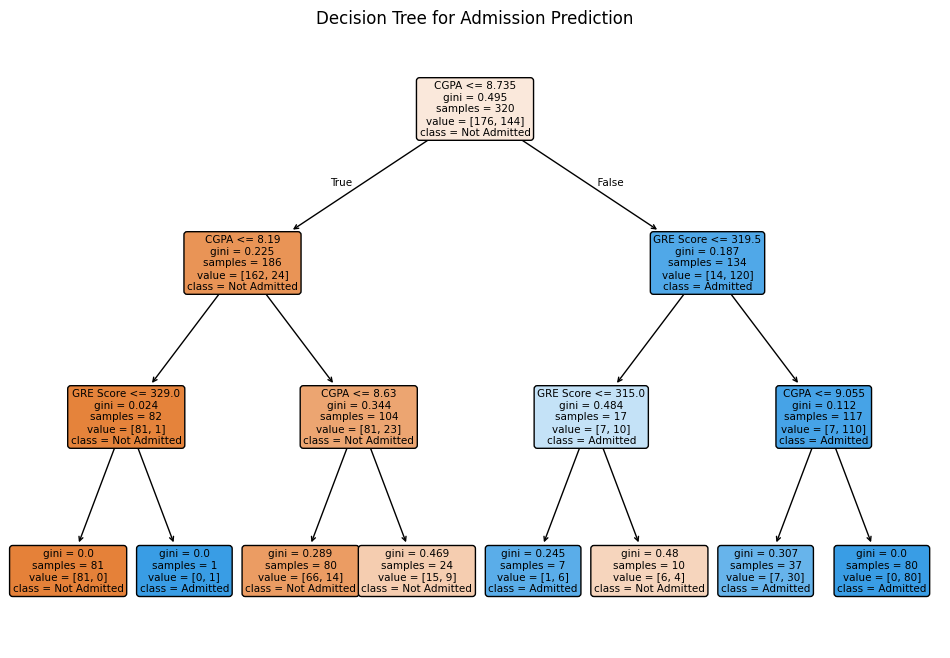

In [ ]:
plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=['GRE Score', 'CGPA'],
    class_names=['Not Admitted', 'Admitted'],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Admission Prediction")
plt.show()

In [ ]:
print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 3))


Accuracy: 0.875


In [ ]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:

[[42  2]
 [ 8 28]]


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.95      0.89        44
           1       0.93      0.78      0.85        36

    accuracy                           0.88        80
   macro avg       0.89      0.87      0.87        80
weighted avg       0.88      0.88      0.87        80

